# **Exploratory Data Analysis (EDA) Penyebab Kematian di Indonesia yang Dilaporkan**

Notebook ini bertujuan untuk mengeksplorasi data penyebab kematian yang dilaporkan di Indonesia, mengidentifikasi tren tahunan, serta melihat distribusi penyebab kematian berdasarkan kategori dan wilayah.



## **1. Import Library dan Load Data**

Langkah awal adalah memuat library yang dibutuhkan untuk manipulasi data dan visualisasi.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Praktikum AVD/Penyebab Kematian di Indonesia yang Dilaporkan - Raw.csv')

df.head()

,Cause,Type,Year,Data Redundancy,Total Deaths,Source,Page at Source,Source URL
0,Abrasi Air Laut,Bencana Alam,2012,1,0,Profil Kesehatan Indonesia Tahun 2012,Lampiran 3.38,https://pusdatin.kemkes.go.id/download.php?fil...
1,AIDS,Bencana Non Alam dan Penyakit,2000,1,47,Profil Kesehatan Indonesia Tahun 2004,78,https://pusdatin.kemkes.go.id/download.php?fil...
2,AIDS,Bencana Non Alam dan Penyakit,2001,1,99,Profil Kesehatan Indonesia Tahun 2004,78,https://pusdatin.kemkes.go.id/download.php?fil...
3,AIDS,Bencana Non Alam dan Penyakit,2002,1,100,Profil Kesehatan Indonesia Tahun 2004,78,https://pusdatin.kemkes.go.id/download.php?fil...
4,AIDS,Bencana Non Alam dan Penyakit,2003,5,261,Profil Kesehatan Indonesia Tahun 2004,78,https://pusdatin.kemkes.go.id/download.php?fil...


## **2. Pemeriksaan Struktur Data**

Memeriksa tipe data, jumlah baris, dan apakah terdapat nilai yang kosong pada dataset.

In [8]:
# Informasi kolom dan tipe data
df.info()

# Lihat nama kolom
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062 entries, 0 to 1061
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Cause            1062 non-null   object
 1   Type             1062 non-null   object
 2   Year             1062 non-null   int64 
 3   Data Redundancy  1062 non-null   int64 
 4   Total Deaths     1062 non-null   int64 
 5   Source           1062 non-null   object
 6   Page at Source   1060 non-null   object
 7   Source URL       1060 non-null   object
dtypes: int64(3), object(5)
memory usage: 66.5+ KB


Index(['Cause', 'Type', 'Year', 'Data Redundancy', 'Total Deaths', 'Source',
       'Page at Source', 'Source URL'],
      dtype='object')

## **3. Statistik Deskriptif**

Melihat ringkasan statistik untuk kolom numerik, terutama pada kolom Total Deaths.

In [9]:
df.describe()

,Year,Data Redundancy,Total Deaths
count,1062.000000,1062.000000,1062.000000
mean,2010.202448,2.932203,1194.364407
std,5.227120,2.776486,6248.983680
min,2000.000000,1.000000,0.000000
25%,2006.000000,1.000000,6.000000
50%,2009.000000,1.000000,42.000000
75%,2014.000000,4.000000,261.000000
max,2022.000000,12.000000,129171.000000


## **4. Pengecekan Missing Values**

Menghitung jumlah dan persentase nilai hilang per kolom untuk mengetahui kolom mana yang reliabel dan kolom mana yang harus diperlakukan hati-hati.

In [11]:
missing = df.isna().sum()
missing

missing_pct = df.isna().mean() * 100
missing_pct

,0
Cause,0.000000
Type,0.000000
Year,0.000000
Data Redundancy,0.000000
Total Deaths,0.000000
Source,0.000000
Page at Source,0.188324
Source URL,0.188324


## **5. Pengecekan Duplikasi**

Data duplikat dapat mempengaruhi hasil analisis sehingga perlu dihapus jika ada.

In [27]:
df.duplicated().sum()

np.int64(332)

Dari pengecekan tersebut, diketahui bahwa tidak terdapat data duplikat

## **6. Data Cleaning**

Kolom yang tidak relevan untuk analisis dihapus agar fokus pada variabel utama.

In [15]:
df = df.drop_duplicates()
df = df.drop(columns=['Data Redundancy', 'Source', 'Page at Source', 'Source URL'])

## **7. Melihat Gambaran Data Secara Sederhana**

### **7.1 Distribusi Jenis Penyebab**



/tmp/ipykernel_922/1232673893.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Type', palette='viridis', order=df['Type'].value_counts().index)


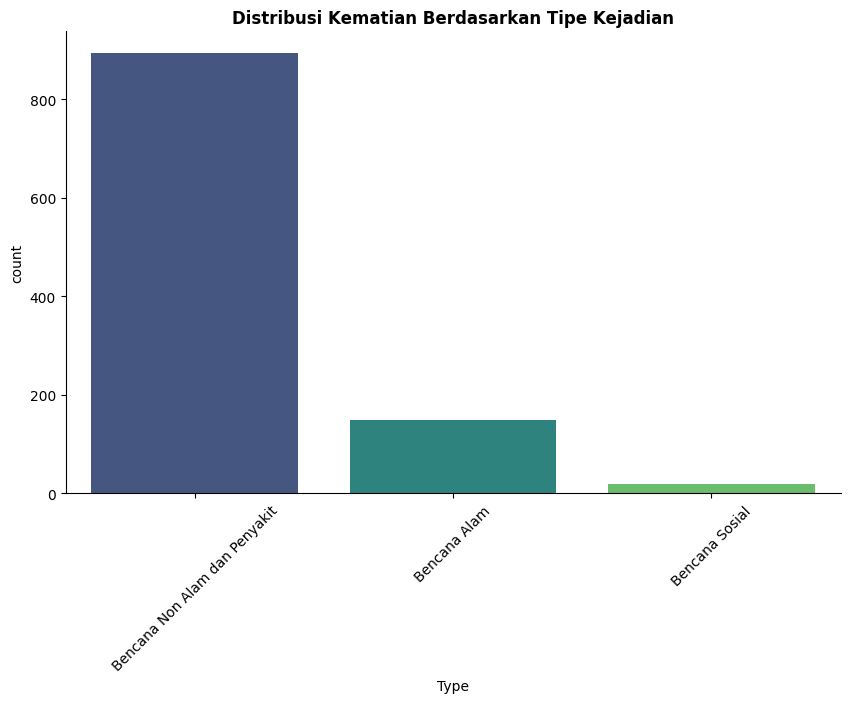

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Type', palette='viridis', order=df['Type'].value_counts().index)
plt.title('Distribusi Kematian Berdasarkan Tipe Kejadian', fontweight='bold')
plt.xticks(rotation=45)
sns.despine()
plt.show()

Plot ini menunjukkan distribusi jenis penyebab kematian, di mana kategori Bencana Non Alam dan Penyakit cenderung lebih dominan dibandingkan Bencana Alam.

### **7.2 Distribusi Jumlah Kematian**

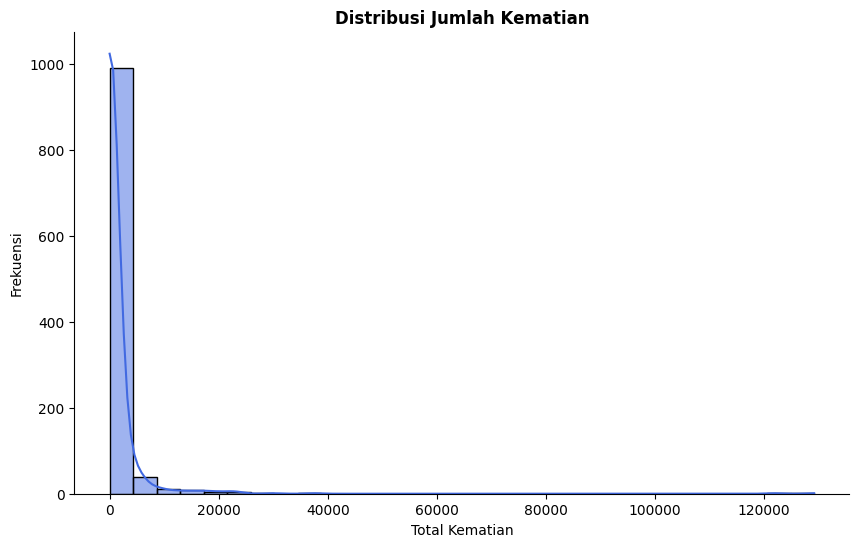

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Total Deaths'], bins=30, kde=True, color='royalblue')
plt.title('Distribusi Jumlah Kematian', fontweight='bold')
plt.xlabel('Total Kematian')
plt.ylabel('Frekuensi')
sns.despine()
plt.show()

Plot ini menunjukkan distribusi jumlah kematian yang cenderung right-skewed, di mana sebagian besar kejadian memiliki jumlah kematian rendah, namun terdapat beberapa kasus dengan jumlah sangat tinggi.

### **7.3 Distribusi Tahun**

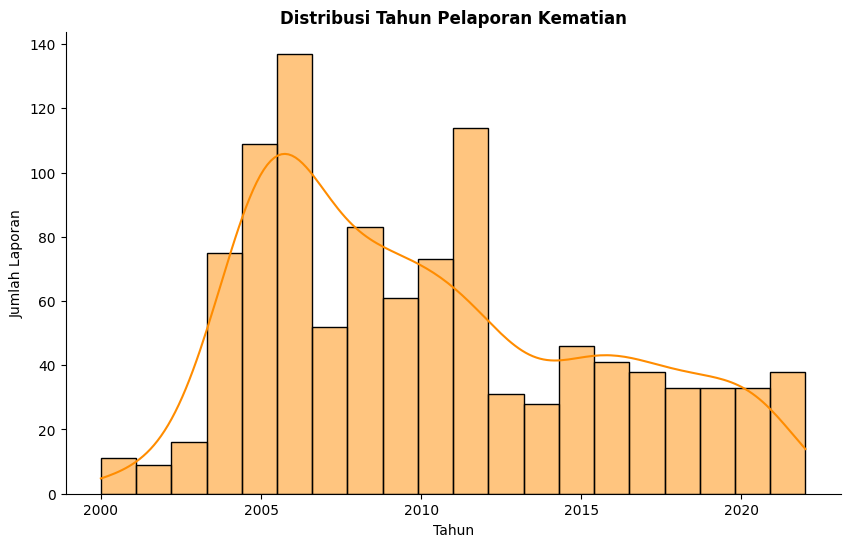

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Year'], bins=20, kde=True, color='darkorange')
plt.title('Distribusi Tahun Pelaporan Kematian', fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Laporan')
sns.despine()
plt.show()

Plot ini menunjukkan sebaran data berdasarkan tahun, yang menggambarkan periode pelaporan data kematian di Indonesia.

## **8. Melihat Hubungan Antar Bagian Data**

### **8.1 Tren Kematian per Tahun**

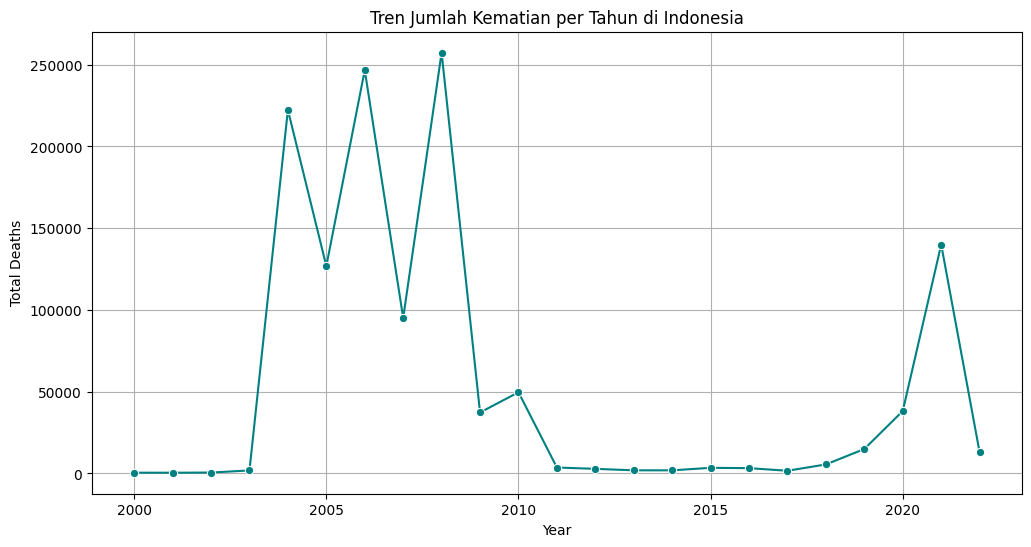

In [25]:
plt.figure(figsize=(12, 6))
annual_deaths = df.groupby('Year')['Total Deaths'].sum().reset_index()
sns.lineplot(data=annual_deaths, x='Year', y='Total Deaths', marker='o', color='teal')
plt.title('Tren Jumlah Kematian per Tahun di Indonesia')
plt.grid(True)
plt.show()

Plot ini menunjukkan tren jumlah kematian dari waktu ke waktu, di mana terdapat fluktuasi yang signifikan pada tahun-tahun tertentu yang kemungkinan disebabkan oleh kejadian luar biasa seperti wabah atau bencana besar.

### **8.2 Kematian Berdasarkan Jenis**

/tmp/ipykernel_922/1251309400.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type', y='Total Deaths', palette='Set2')


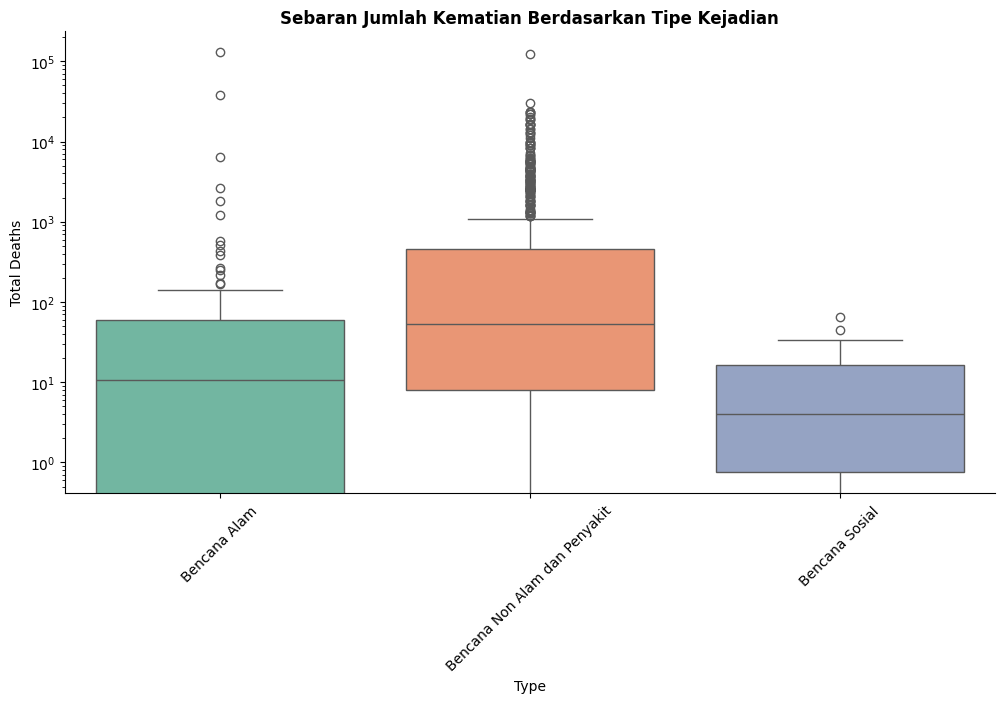

In [31]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Type', y='Total Deaths', palette='Set2')
plt.title('Sebaran Jumlah Kematian Berdasarkan Tipe Kejadian', fontweight='bold')
plt.xticks(rotation=45)
plt.yscale('log')
sns.despine()
plt.show()

Plot ini menunjukkan bahwa kategori Bencana Non Alam dan Penyakit memiliki variasi jumlah kematian yang lebih tinggi dibandingkan Bencana Alam, termasuk beberapa nilai ekstrem.

### **8.3 Top Penyebab Kematian**

/tmp/ipykernel_922/1178922723.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_causes.values, y=top_causes.index, palette='magma')


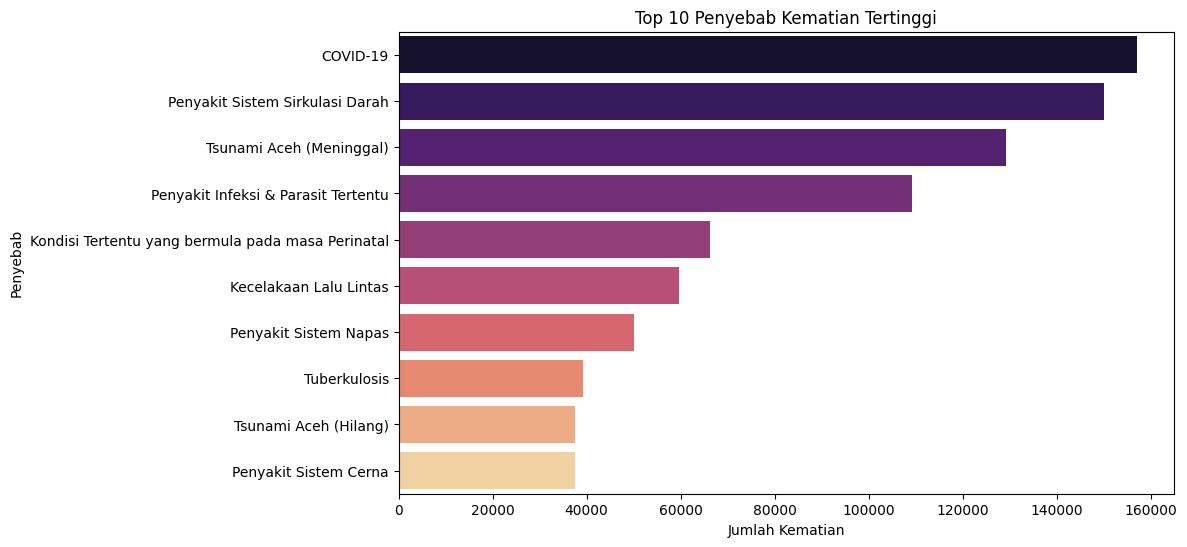

In [24]:
plt.figure(figsize=(10, 6))
top_causes = df.groupby('Cause')['Total Deaths'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_causes.values, y=top_causes.index, palette='magma')
plt.title('Top 10 Penyebab Kematian Tertinggi')
plt.xlabel('Jumlah Kematian')
plt.ylabel('Penyebab')
plt.show()

Plot ini menunjukkan penyebab kematian dengan jumlah tertinggi, yang didominasi oleh penyakit dibandingkan bencana alam.

### **8.4 Heatmap Korelasi**

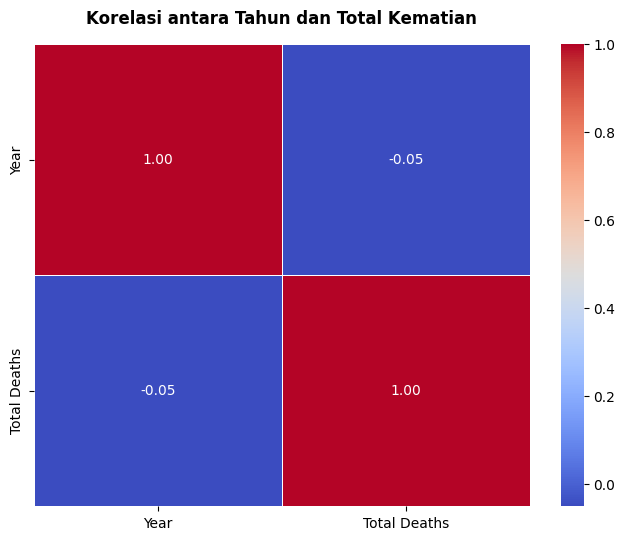

In [32]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Year', 'Total Deaths']].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi antara Tahun dan Total Kematian', fontweight='bold', pad=15)
plt.show()

Heatmap ini menunjukkan hubungan antar variabel numerik. Korelasi antara tahun dan jumlah kematian biasanya lemah, yang berarti tidak selalu terjadi peningkatan atau penurunan yang konsisten tiap tahun.

## **9. Ringkasan**

*   Penyebab kematian di Indonesia didominasi oleh faktor non-alam seperti penyakit.
*   Distribusi jumlah kematian tidak merata dan cenderung memiliki outlier.
*   Terdapat fluktuasi jumlah kematian tiap tahun yang dipengaruhi oleh kejadian tertentu.
*   Beberapa penyebab memiliki kontribusi yang jauh lebih besar dibanding lainnya.

